# DecodeLabs Data Science – Project 4
## NLP & Sentiment Analysis

**Pipeline:** Text preprocessing → TF-IDF → Multinomial Naive Bayes → Sentiment prediction

> Note: The provided order dataset does not contain genuine review text or a sentiment label. This notebook therefore creates a simple text representation from the available order fields and derives sentiment from `OrderStatus` for demonstration purposes.


In [7]:
# 1. Import libraries

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_da

True

In [8]:
# 2. Load dataset

file_path = "Dataset for Data Analytics - Sheet1.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Dataset shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [9]:
# 3. Basic data exploration

print("Missing values:")
display(df.isnull().sum())

print("\nOrder Status distribution:")
display(df["OrderStatus"].value_counts())

print("\nProduct distribution:")
display(df["Product"].value_counts())


Missing values:


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


Order Status distribution:


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


Product distribution:


Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [10]:
# 4. Create textual representation

df["text"] = (
    "I ordered a "
    + df["Product"].astype(str)
    + " and the order was "
    + df["OrderStatus"].astype(str)
    + ". Payment was made using "
    + df["PaymentMethod"].astype(str)
    + "."
)

display(df[["Product", "OrderStatus", "PaymentMethod", "text"]].head())


,Product,OrderStatus,PaymentMethod,text
0,Monitor,Shipped,Debit Card,I ordered a Monitor and the order was Shipped....
1,Phone,Shipped,Online,I ordered a Phone and the order was Shipped. P...
2,Tablet,Cancelled,Credit Card,I ordered a Tablet and the order was Cancelled...
3,Chair,Returned,Debit Card,I ordered a Chair and the order was Returned. ...
4,Printer,Delivered,Online,I ordered a Printer and the order was Delivere...


In [11]:
# 5. Create sentiment labels from OrderStatus
# Positive: Delivered / Shipped
# Negative: Cancelled / Returned

positive_status = ["Delivered", "Shipped"]
negative_status = ["Cancelled", "Returned"]

df["Sentiment"] = df["OrderStatus"].apply(
    lambda x: (
        "Positive" if x in positive_status
        else "Negative" if x in negative_status
        else np.nan
    )
)

df = df.dropna(subset=["Sentiment"]).copy()

print("Sentiment distribution:")
display(df["Sentiment"].value_counts())


Sentiment distribution:


Sentiment
Negative    497
Positive    466
Name: count, dtype: int64

In [13]:
# 6. Text preprocessing
# Tokenization + stop-word removal + POS-guided WordNet lemmatization

stop_words = set(stopwords.words("english"))

# Keep negation words because they can affect sentiment
negation_words = {"no", "not", "never", "nor"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    tokens = nltk.word_tokenize(text)

    cleaned_tokens = []

    for word in tokens:
        if word not in stop_words:
            pos = nltk.pos_tag([word])[0][1]

            if pos.startswith("J"):
                wordnet_pos = "a"
            elif pos.startswith("V"):
                wordnet_pos = "v"
            elif pos.startswith("N"):
                wordnet_pos = "n"
            elif pos.startswith("R"):
                wordnet_pos = "r"
            else:
                wordnet_pos = "n"

            cleaned_tokens.append(
                lemmatizer.lemmatize(word, wordnet_pos)
            )

    return " ".join(cleaned_tokens)

df["clean_text"] = df["text"].apply(preprocess_text)

display(df[["text", "clean_text"]].head())


,text,clean_text
0,I ordered a Monitor and the order was Shipped....,order monitor order ship payment make use debi...
1,I ordered a Phone and the order was Shipped. P...,order phone order ship payment make use online
2,I ordered a Tablet and the order was Cancelled...,order tablet order cancel payment make use cre...
3,I ordered a Chair and the order was Returned. ...,order chair order return payment make use debi...
4,I ordered a Printer and the order was Delivere...,order printer order deliver payment make use o...


In [14]:
# 7. Compare original and processed text

for i in range(min(5, len(df))):
    print("Original:")
    print(df.iloc[i]["text"])
    print("\nProcessed:")
    print(df.iloc[i]["clean_text"])
    print("-" * 70)


Original:
I ordered a Monitor and the order was Shipped. Payment was made using Debit Card.

Processed:
order monitor order ship payment make use debit card
----------------------------------------------------------------------
Original:
I ordered a Phone and the order was Shipped. Payment was made using Online.

Processed:
order phone order ship payment make use online
----------------------------------------------------------------------
Original:
I ordered a Tablet and the order was Cancelled. Payment was made using Credit Card.

Processed:
order tablet order cancel payment make use credit card
----------------------------------------------------------------------
Original:
I ordered a Chair and the order was Returned. Payment was made using Debit Card.

Processed:
order chair order return payment make use debit card
----------------------------------------------------------------------
Original:
I ordered a Printer and the order was Delivered. Payment was made using Online.

Proces

In [15]:
# 8. Train/test split

X = df["clean_text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 770
Testing samples: 193


In [16]:
# 9. TF-IDF vectorization
# Unigrams + bigrams and a feature limit to control dimensionality

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (770, 53)
Testing TF-IDF shape: (193, 53)


In [17]:
# 10. Inspect sparse matrix

print("Matrix type:", type(X_train_tfidf))
print("Rows:", X_train_tfidf.shape[0])
print("Features:", X_train_tfidf.shape[1])
print("Non-zero values:", X_train_tfidf.nnz)

sparsity = 1 - (
    X_train_tfidf.nnz /
    (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
)

print("Sparsity:", round(sparsity, 4))


Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Rows: 770
Features: 53
Non-zero values: 11676
Sparsity: 0.7139


In [18]:
# 11. Train Multinomial Naive Bayes

model = MultinomialNB(alpha=1.0)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed.")


Model training completed.


In [19]:
# 12. Predictions

y_pred = model.predict(X_test_tfidf)

print("First predictions:")
print(y_pred[:20])


First predictions:
['Positive' 'Positive' 'Negative' 'Negative' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative']


In [20]:
# 13. Evaluate model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       100
    Positive       1.00      1.00      1.00        93

    accuracy                           1.00       193
   macro avg       1.00      1.00      1.00       193
weighted avg       1.00      1.00      1.00       193



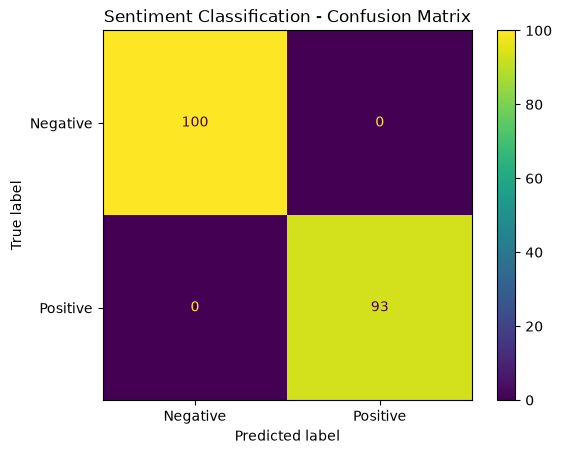

In [21]:
# 14. Confusion matrix

labels = ["Negative", "Positive"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Sentiment Classification - Confusion Matrix")
plt.show()


In [22]:
# 15. Test the model with new text

new_reviews = [
    "The order was delivered successfully and everything was good",
    "My order was cancelled and I am very unhappy",
    "The product was shipped quickly",
    "I returned the product because the order was bad"
]

new_reviews_clean = [
    preprocess_text(review)
    for review in new_reviews
]

new_reviews_tfidf = tfidf.transform(new_reviews_clean)

predictions = model.predict(new_reviews_tfidf)
probabilities = model.predict_proba(new_reviews_tfidf)

for review, prediction, probability in zip(
    new_reviews,
    predictions,
    probabilities
):
    print("\nReview:", review)
    print("Predicted sentiment:", prediction)
    print("Negative probability:", round(probability[0], 3))
    print("Positive probability:", round(probability[1], 3))



Review: The order was delivered successfully and everything was good
Predicted sentiment: Positive
Negative probability: 0.004
Positive probability: 0.996

Review: My order was cancelled and I am very unhappy
Predicted sentiment: Negative
Negative probability: 0.996
Positive probability: 0.004

Review: The product was shipped quickly
Predicted sentiment: Positive
Negative probability: 0.018
Positive probability: 0.982

Review: I returned the product because the order was bad
Predicted sentiment: Negative
Negative probability: 0.976
Positive probability: 0.024


In [23]:
# 16. Display important TF-IDF features

feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).flatten()

top_indices = mean_tfidf.argsort()[-20:][::-1]

print("Top TF-IDF features:\n")

for index in top_indices:
    print(
        feature_names[index],
        "->",
        round(mean_tfidf[index], 4)
    )


Top TF-IDF features:

order -> 0.2031
payment make -> 0.12
payment -> 0.12
make use -> 0.12
use -> 0.12
make -> 0.12
card -> 0.1042
cancel -> 0.0738
cancel payment -> 0.0738
order cancel -> 0.0738
order return -> 0.0719
return payment -> 0.0719
return -> 0.0719
order deliver -> 0.0706
deliver -> 0.0706
deliver payment -> 0.0706
order ship -> 0.0696
ship -> 0.0696
ship payment -> 0.0696
use online -> 0.0687


In [24]:
# 17. Save processed dataset

output_df = df[
    [
        "OrderID",
        "Product",
        "OrderStatus",
        "text",
        "clean_text",
        "Sentiment"
    ]
]

output_df.to_csv(
    "processed_sentiment_dataset.csv",
    index=False
)

print("Processed dataset saved as processed_sentiment_dataset.csv")


Processed dataset saved as processed_sentiment_dataset.csv


## Conclusion

The notebook implements the requested NLP pipeline:

1. Text ingestion
2. Tokenization
3. Stop-word removal while preserving negations
4. POS-guided WordNet lemmatization
5. TF-IDF vectorization with unigrams and bigrams
6. Sparse matrix representation
7. Multinomial Naive Bayes classification
8. Sentiment prediction and evaluation

**Important:** Because the supplied CSV is an order dataset rather than a genuine review dataset, the sentiment labels are derived from `OrderStatus`. For a genuine sentiment-analysis result, replace this dataset with one containing actual review text and sentiment labels.
